In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
from tqdm import tqdm
import scipy as sp
from copy import deepcopy 

# LISA tools
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix, AET1SensitivityMatrix
from bbhx.waveformbuild import BBHWaveformFD

# My modules
from tools.LISASimulator import LISASimulator
from tools.time_freq_likelihood import TimeFreqLikelihood
from tools.likelihood import get_dh, get_hh, TimeFreqSNR
import tools.likelihood as likelihood

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


In [3]:
Tobs = 1*YRSID_SI/12
dt = 5.
include_T_channel = False # Set to True if you want to include the T channel in the simulation, otherwise only A and E channels will be included.
gpu = False
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)

sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

print(sim.SNR_optimal()[0])

1778.7693378911454


## Pre-Merger

In [4]:
# Not doing the premerger now to see if the code works better with the merger included
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60

def pre_merger(gravitational_wave_data_t, time_before_merger, t_ref, t_array):
        cutoff_time = t_ref - time_before_merger
        cutoff_index = np.searchsorted(t_array, cutoff_time)
        data_t_truncated = gravitational_wave_data_t[:, :cutoff_index]
        return data_t_truncated, cutoff_index

data_t_truncated,   cutoff_index =  pre_merger(data_t, time_before_merger, t_ref, t_array)
signal_t_truncated, cutoff_index =  pre_merger(sim.signal_t[0], time_before_merger, t_ref, t_array)

(1041,) (483,) 502803


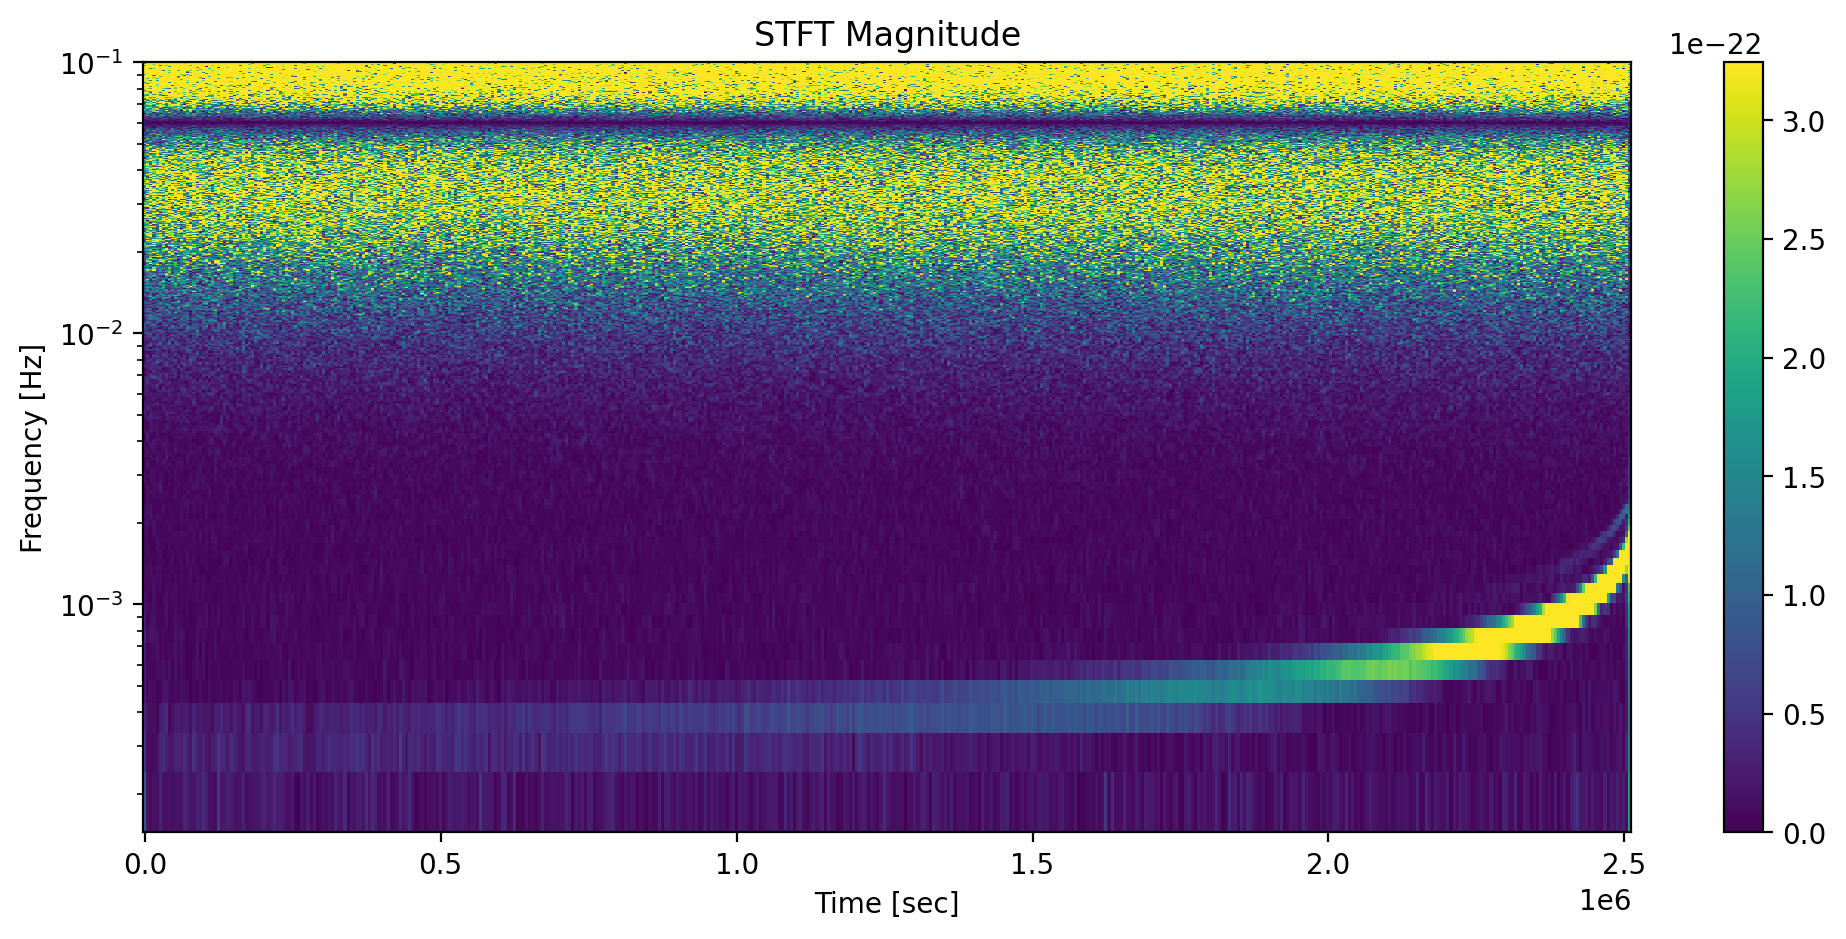

In [5]:
f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=2081)

print(f.shape, t.shape, f.shape[0]*t.shape[0])

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()

# Differential Evolution Analysis

In [12]:
from bbhx.utils.constants import *
import numpy as np
import scipy as sp
from scipy.optimize import OptimizeResult
import time
import os
import pickle
from copy import deepcopy
import matplotlib.pyplot as plt

from lisatools.sensitivity  import SensitivityMatrix, AET1SensitivityMatrix, get_sensitivity, AE1SensitivityMatrix
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.datacontainer import DataResidualArray
from typing import Any, Tuple, Optional, List, Dict

# variable names:

# parameters_10 = [mT,  q, a1, a2,                   phi,        cos(i), lambda, sin(beta), psi, t_ref]
# parameters_11 = [mT,  q, a1, a2, dL/(PC_SI * 1e6), phi,        cos(i), lambda, sin(beta), psi, t_ref]
# parameters_all= [m1, m2, a1, a2, dL              , phi, f_ref,     i , lambda,     beta , psi, t_ref] = parameters_bbhx
# results.x is same as parameters_10 i.e. transformed parameters without distance and f_ref

def transform_parameters_to_bbhx(x_11: np.ndarray, cutoff_time=None) -> np.ndarray:
    """
    Transform parameters to BBHX format. 
    - x: array of 11 parameters: [mT, q, a1, a2, dL/(PC_SI * 1e6), phi, cos(i), lambda, sin(beta), psi, t_ref]
    Returns 
    - all_parameters: an array of 12 parameters (input for bbhx): [m1, m2, a1, a2, dL, phi, f_ref, i, lambda, beta, psi, t_ref]
    """

    all_parameters = np.zeros(12)
    mT = np.exp(x_11[0])
    q  = x_11[1]
    all_parameters[0] = mT / (1 + q)
    all_parameters[1] = mT * q / (1 + q)
    all_parameters[2] = x_11[2]
    all_parameters[3] = x_11[3]
    all_parameters[4] = x_11[4] * PC_SI * 1e9
    all_parameters[5] = x_11[5]
    all_parameters[6] = 0.0
    all_parameters[7] = np.arccos(x_11[6])
    all_parameters[8] = x_11[7]
    all_parameters[9] = np.arcsin(x_11[8])
    all_parameters[10] = x_11[9]
    all_parameters[11] = cutoff_time + x_11[10]*(60*60*24) if cutoff_time is not None else x_11[10]
    return all_parameters

def transform_bbhx_to_parameters(x: np.ndarray, cutoff_time=None) -> np.ndarray:
    """ Transform parameters to a format that can be used for analysis.
    - x: array of 12 true parameters: [m1, m2, a1, a2, dL, phi, f_ref, i, lambda, beta, psi, t_ref]
    Returns
    - all_parameters: an array of 11 parameters: [mT, q, a1, a2, dL/(PC_SI * 1e6), phi, cos(i), lambda, sin(beta), psi, t_ref]
    """
    all_parameters = np.zeros(11)
    all_parameters[0] = np.log(x[0] + x[1])
    all_parameters[1] = x[1] / x[0]
    all_parameters[2] = x[2]
    all_parameters[3] = x[3]
    all_parameters[4] = x[4] / (PC_SI * 1e9)
    all_parameters[5] = x[5]
    all_parameters[6] = np.cos(x[7]) # neglecting f_ref as it is not used in the analysis by jumping directly to x[7]
    all_parameters[7] = x[8]
    all_parameters[8] = np.sin(x[9])
    all_parameters[9] = x[10]
    all_parameters[10] = (x[11] - cutoff_time)/(60*60*24) if cutoff_time is not None else x[11]  # Subtract cutoff_time from t_ref if provided, otherwise keep it as is
    return all_parameters

class MBHB_finder_time_frequency:
    def __init__(self, data_t, wave_gen, waveform_kwargs, boundaries, cutoff_time, nperseg = 15000, dt_full=5.0, pre_merger=False, cutoff_index=None, true_parameters=None):
        self.data_t = data_t
        self.wave_gen = wave_gen
        self.dt_full = dt_full                  # This is the time step for the full data, not the STFT
        self.cutoff_index = cutoff_index        # Index to truncate the data before merger
        self.cutoff_time = cutoff_time         # Time until when data is observed
        self.pre_merger = pre_merger            # Flag to indicate if the data is pre-merger

        # All the following quantities are for after the STFT is calculated
        self.dt = None
        self.nperseg = nperseg
        self.f = None
        self.t = None
        self.Zxx_data_A = None
        self.Zxx_data_E = None
        self.sens_mat_new = None
        self.dd = None

        # waveform kwargs
        self.waveform_kwargs = waveform_kwargs
        self.boundaries = boundaries                            # boundaries for the 11 parameters including distance as a dictionary.
        self.parameter_names = list(self.boundaries.keys())     # List of parameter names from the boundaries dictionary

        # Initialize found parameters and true parameters
        self.true_parameters = true_parameters

        # Others
        self.history = []

    def __str__(self):
        if self.true_parameters is None:
            raise ValueError("True parameters are not set. Please provide true parameters to the MBHB_finder instance.")

        from io import StringIO
        buffer = StringIO()

        param_names = list(self.boundaries.keys())
        transformed_true = transform_bbhx_to_parameters(self.true_parameters, self.cutoff_time)

        # Use multiple columns for multiple runs
        if hasattr(self, "found_parameters_11_all"):
            num_runs = self.found_parameters_11_all.shape[0]

            # Header
            header = f"{'Index':<5} {'Parameter':<25} {'Lower Bound':<15}"
            for run in range(num_runs):
                header += f"{f'Found {run+1}':<20}"
            header += f"{'True':<20} {'Upper Bound':<15} {'Status':<10}"
            buffer.write(header + "\n")
            buffer.write('-' * len(header) + '\n')

            for i, param in enumerate(param_names):
                lower, upper = self.boundaries[param]
                true = transformed_true[i]

                if param == 'Distance':
                    status = 'variable'
                elif param in self.fixed_parameters:
                    status = 'fixed'
                else:
                    status = 'variable'

                row = f"{i:<5} {param:<25} {lower:<15.6g}"
                for run in range(num_runs):
                    found = self.found_parameters_11_all[run, i]
                    row += f"{found:<20.6g}"
                row += f"{true:<20.6g} {upper:<15.6g} {status:<10}"
                buffer.write(row + "\n")

            # SNRs
            buffer.write("\nSNRs for each run:\n")
            for i, snr in enumerate(self.SNR_all):
                buffer.write(f"Run {i+1:<2}: SNR = {snr:.8f}\n")

        return buffer.getvalue()


    def callback(self, intermediate_result: OptimizeResult):
        """
        Callback function to store the history of the optimization process.
        """
        self.history.append({
            'xk': intermediate_result.x.copy(),
            'fun': intermediate_result.fun,
            'nit': intermediate_result.nit,
            'message': intermediate_result.message,
            'success': intermediate_result.success,
            'convergence': intermediate_result.convergence
        })


    def get_stft_of_data(self, include_sens_kwargs=False):
        f, t, Zxx_data_A = sp.signal.stft(self.data_t[0], fs=1/self.dt_full, nperseg=self.nperseg)
        f, t, Zxx_data_E = sp.signal.stft(self.data_t[1], fs=1/self.dt_full, nperseg=self.nperseg)
        
        self.f = f
        self.df = f[1] - f[0]  # frequency bin width
        self.f[0] = self.f[1]  # set the first frequency to the second frequency to avoid division by zero
        
        self.t = t
        self.dt = t[1] - t[0]

        self.Zxx_data_A = Zxx_data_A
        self.Zxx_data_E = Zxx_data_E

        if include_sens_kwargs:
            sens_kwargs = dict(stochastic_params=(self.Tobs,))
            self.sens_mat_new = AE1SensitivityMatrix(self.f, **sens_kwargs).sens_mat
        else:
            self.sens_mat_new = AE1SensitivityMatrix(self.f).sens_mat

    def get_hh(self, Zxx_A, Zxx_E):
        inner_product_A = np.abs(Zxx_A)**2 / self.sens_mat_new[0][:, np.newaxis]
        inner_product_E = np.abs(Zxx_E)**2 / self.sens_mat_new[1][:, np.newaxis]
        
        return 4 * self.df * np.sum(inner_product_A + inner_product_E)
    
    def get_dh(self, Zxx_A, Zxx_E):
        inner_product_A = (Zxx_A * np.conj(self.Zxx_data_A)) / self.sens_mat_new[0][:, np.newaxis] 
        inner_product_E = (Zxx_E * np.conj(self.Zxx_data_E)) / self.sens_mat_new[1][:, np.newaxis]

        return 4 * self.df * np.sum(inner_product_A.real + inner_product_E.real)

    def calculate_amplitude(self, parameters_11: Any):

        # Transform the parameters to BBHX format by adding f_ref = 0.0
        parameters_bbhx = transform_parameters_to_bbhx(parameters_11, self.cutoff_time)
        
        # Generate the waveform template with parameters_bbhx and remove the T channel
        template_f = self.wave_gen(*parameters_bbhx, **self.waveform_kwargs)[0]
        template_f = template_f[:2]
        template_t = np.fft.irfft(template_f, axis=-1)

        # Truncate the template to the same length as the data i.e. pre-merger
        if self.pre_merger:
            template_t = template_t[:, :self.cutoff_index]
        
        # Calculate the STFT of the template and calculate the inner products
        Zxx_temp_A = sp.signal.stft(template_t[0], fs=1/self.dt, nperseg=self.nperseg)[2]
        Zxx_temp_E = sp.signal.stft(template_t[1], fs=1/self.dt, nperseg=self.nperseg)[2]
        hh = self.get_hh(Zxx_temp_A, Zxx_temp_E)
        dh = self.get_dh(Zxx_temp_A, Zxx_temp_E)

        # Calculate the amplitude factor = <d|h> / <h|h> 
        amplitude = dh/hh
        
        return amplitude
    
    def calculate_time_frequency_SNR_with_distance(
        self,
        parameters: Any,
        ):
        """ Calculate the time-frequency SNR with distance parameter.
        - parameters: [mT,  q, a1, a2, dL/(PC_SI * 1e6), phi, cos(i), lambda, sin(beta), psi, t_ref-cutoff_time]
        """

        # Transform the parameters to BBHX format by adding f_ref = 0.0
        parameters_bbhx = transform_parameters_to_bbhx(parameters, self.cutoff_time) 

        # Generate the waveform template with parameters_bbhx and remove the T channel
        template_f = self.wave_gen(*parameters_bbhx, **self.waveform_kwargs)[0]
        template_f = template_f[:2] # remove T channel
        template_t = np.fft.irfft(template_f, axis=-1)

        # Truncate the template to the same length as the data i.e. pre-merger
        if self.pre_merger:
            template_t = template_t[:, :self.cutoff_index]

        # Calculate the STFT of the template
        Zxx_temp_A = sp.signal.stft(template_t[0], fs=1/self.dt, nperseg=self.nperseg)[2]
        Zxx_temp_E = sp.signal.stft(template_t[1], fs=1/self.dt, nperseg=self.nperseg)[2]

        # Calculate the inner product for A and E channels
        hh = self.get_hh(Zxx_temp_A, Zxx_temp_E)
        dh = self.get_dh(Zxx_temp_A, Zxx_temp_E)

        # Return the normal positive SNR value as we are not optimizing this function
        return dh / np.sqrt(hh) 
    
    def calculate_time_frequency_SNR_without_distance(
        self,
        variable_parameters: np.ndarray,
        fixed_parameters: Optional[Dict[str, Any]] = None,
    ) -> float:
        """ Calculate the time-frequency SNR without distance parameter.
        - variable_parameters: the parameters that need to be optimized with differential evolution
        - fixed_parameters: dictionary of fixed parameters. Always include {'Distance': 1e6} as a fixed parameter

        For the most general case, have variable_parameters = parameters_10: [mT,  q, a1, a2, phi, cos(i), lambda, sin(beta), psi, t_ref]
        Since distance does not affect the SNR, it is set to a constant value.
        f_ref = 0.0 is added to the parameters in the function transform_parameters_to_bbhx to be compatible with the waveform generator. 
        
        Returns:
        - -SNR: the negative SNR value, as we want to minimize the SNR.
        """
        #start_time = time.time()
        # Combine fixed and variable parameters into a single array of 11 parameters
        parameters_11 = []
        variable_parameter_index = 0
        for name in self.parameter_names:
            if name in fixed_parameters:
                parameters_11.append(fixed_parameters[name])
            else:
                parameters_11.append(variable_parameters[variable_parameter_index])
                variable_parameter_index += 1
        parameters_11 = np.array(parameters_11)
        #print("Time to combine parameters:", time.time() - start_time)
        # Transform to BBHX parameters
        parameters_bbhx = transform_parameters_to_bbhx(parameters_11, self.cutoff_time)

        # Generate the waveform template with parameters_bbhx and remove the T channel
        template_f = self.wave_gen(*parameters_bbhx, **self.waveform_kwargs)[0]
        #print("Time to generate waveform template:", time.time() - start_time)
        #start_time = time.time()
        template_f = template_f[:2] # remove T channel
        template_t = np.fft.irfft(template_f, axis=-1)

        # Truncate the template to the same length as the data i.e. pre-merger
        if self.pre_merger:
            template_t = template_t[:, :self.cutoff_index]

        # Calculate the STFT of the template
        Zxx_temp_A = sp.signal.stft(template_t[0], fs=1/self.dt, nperseg=self.nperseg)[2]
        Zxx_temp_E = sp.signal.stft(template_t[1], fs=1/self.dt, nperseg=self.nperseg)[2]
        #print("Time to calculate STFT of template:", time.time() - start_time)
        # Calculate the inner products for A and E channels
        hh = self.get_hh(Zxx_temp_A, Zxx_temp_E)
        dh = self.get_dh(Zxx_temp_A, Zxx_temp_E)
        #print("Time to calculate inner products:", time.time() - start_time)
        # Return the negative SNR value, as we want to minimize the SNR
        return - dh / np.sqrt(hh)

    def find_MBHB(self, 
                  number_of_searches= 1,
                  differential_evolution_kwargs = None, 
                  fixed_parameters: Optional[Dict[str, Any]] = None):

        if fixed_parameters is None:
            fixed_parameters = {list(self.boundaries.items())[4][0] : list(self.boundaries.items())[4][1][0] + 0.5 * (list(self.boundaries.items())[4][1][1] - list(self.boundaries.items())[4][1][0])}


        self.fixed_parameters = fixed_parameters

        variable_parameter_names = [name for name in self.parameter_names if name not in fixed_parameters]
        bounds = np.array([self.boundaries[name] for name in variable_parameter_names])
        
        found_parameters_11_all = []
        SNR_all = []
        results_all = []
        parameters_history = []

        for search_index in range(number_of_searches):

            self.history = [] 

            #if differential_evolution_kwargs['init'] != 'sobol':
            #    differential_evolution_kwargs['x0'] = np.random.uniform(low=bounds[:, 0], high=bounds[:, 1])   # Random initial guess for the 10 parameters (all except dL & f_ref)

            #time_start = time.time()
            #SNR = self.calculate_time_frequency_SNR_without_distance(variable_parameters=initial_guess_without_distance, fixed_parameters=fixed_parameters)
            #print('time SNR ',np.round(time.time() - time_start,2))
            #print('initial guess', SNR)
            #time_start = time.time()
            print("Starting differential evolution")
            
            solver = RestartingDESolver(
                func=self.calculate_time_frequency_SNR_without_distance,
                bounds=bounds,
                args=(fixed_parameters,),
                callback=self.callback,   # see new signature below
                diversity_threshold=1e-6,
                restart_fraction=0.3,
                **differential_evolution_kwargs
            )
            results = solver.solve()

            results_all.append(results)
            
            # Store the history of the optimization process
            parameters_history.append([step['xk'] for step in self.history])

            # Extract the optimized parameters from the results and combine them with the fixed parameters
            found_parameters = {}                                                                                # This will hold the complete set of parameters, both fixed and optimized
            variable_parameter_index = 0                                                                         # Index to track where we are in results.x (the optimized free parameters)

            for name in self.parameter_names:
                if name in fixed_parameters:
                    # If this parameter was fixed, take its value directly from the fixed_parameters dictionary
                    found_parameters[name] = fixed_parameters[name]
                else:
                    # If this parameter was optimized by differential evolution, take its value from results.x
                    found_parameters[name] = results.x[variable_parameter_index]
                    variable_parameter_index += 1                                                                # Move to the next optimized parameter

            found_parameters_11 = np.array([found_parameters[name] for name in self.parameter_names])
            
            # Calculate the amplitude factor and normalize the distance parameter to get the true distance MLE
            amplitude_factor = self.calculate_amplitude(found_parameters_11)
            found_parameters_11[4] /= amplitude_factor

            found_parameters_11_all.append(found_parameters_11)
            SNR_all.append(self.calculate_time_frequency_SNR_with_distance(found_parameters_11))                 # function calculate_time_frequency_SNR_with_distance does not multiply the SNR by -1

        found_parameters_11_all = np.array(found_parameters_11_all)
        SNR_all = np.array(SNR_all)
        results_all = np.array(results_all)
        parameters_history = np.array(parameters_history)

        # Find the maximum SNR and the corresponding parameters. Taking argmax because the function calculate_time_frequency_SNR_with_distance does not multiply the SNR by -1
        max_index = np.argmax(SNR_all)
        found_parameters_11_max = found_parameters_11_all[max_index]
        SNR_max = SNR_all[max_index]
        results_max = results_all[max_index]
        parameters_history_max = parameters_history[max_index]

        # Store the found parameters and SNR values
        self.found_parameters_11_all = found_parameters_11_all
        self.SNR_all = SNR_all

        self.found_parameters_11_max = found_parameters_11_max
        self.SNR_max = SNR_max

        return found_parameters_11_max, SNR_max, results_max, parameters_history_max
    



In [18]:
import numpy as np
import inspect
from scipy.optimize._differentialevolution import DifferentialEvolutionSolver
from scipy.optimize import OptimizeResult

class RestartingDESolver(DifferentialEvolutionSolver):
    """
    Differential Evolution with automatic diversity-based restarts.

    Works with multiple SciPy versions:
    - Does NOT call `_prepare()` (since some versions don’t have it).
    - Uses internal DE methods that have been stable for years:
      `_calculate_population_energies`, `_evolve`, `_converged`.

    Callback compatibility:
      - If your callback signature is `callback(OptimizeResult)`, we pass an OptimizeResult.
      - If it is `callback(xk, convergence)`, we pass those two.
      - If it is `callback(best_x, best_fun, nit, population)`, we pass the full info.
    """
    def __init__(self, *args, diversity_threshold=1e-6, restart_fraction=0.3, **kwargs):
        self.diversity_threshold = float(diversity_threshold)
        self.restart_fraction = float(restart_fraction)
        super().__init__(*args, **kwargs)

        # History (optional; useful for plotting/diagnostics)
        self.best_values_ = []     # list of best fun per generation
        self.diversity_ = []       # list of diversity per generation
        self.nit = 0

    # ---- small helper: flexible callback calling ----
    def _call_user_callback(self, nit):
        if self.callback is None:
            return False

        best_x = self.best.copy()
        best_fun = float(self.best_energy)
        pop = self.population.copy()

        # Try to detect callback signature
        try:
            nparams = len(inspect.signature(self.callback).parameters)
        except Exception:
            nparams = None

        try:
            if nparams == 2:
                # SciPy-style: callback(xk, convergence)
                # We don't have a precise "convergence" metric; pass diversity or None.
                conv = self.diversity_[-1] if len(self.diversity_) else None
                return bool(self.callback(best_x, conv))
            elif nparams == 4:
                # Extended: callback(best_x, best_fun, nit, population)
                return bool(self.callback(best_x, best_fun, nit, pop))
            elif nparams == 1:
                # User expects OptimizeResult
                inter = OptimizeResult(
                    x=best_x,
                    fun=best_fun,
                    nit=nit,
                    message=None,
                    success=None,
                    convergence=(self.diversity_[-1] if len(self.diversity_) else None),
                )
                return bool(self.callback(inter))
            else:
                # Fallback: pass OptimizeResult
                inter = OptimizeResult(
                    x=best_x,
                    fun=best_fun,
                    nit=nit,
                    population=pop,
                    convergence=(self.diversity_[-1] if len(self.diversity_) else None),
                )
                return bool(self.callback(inter))
        except TypeError:
            # If introspection failed or signature mismatched, try SciPy style
            conv = self.diversity_[-1] if len(self.diversity_) else None
            return bool(self.callback(best_x, conv))

    def _iter(self):
        """
        One full DE run (up to maxiter or convergence).
        Adds diversity-based restarts when the population collapses.
        """
        for nit in range(1, self.maxiter + 1):
            # Evaluate current population energies (and possibly re-shuffle population)
            self.population_energies, self.population = self._calculate_population_energies(self.population)

            # Track best individual
            best_idx = np.argmin(self.population_energies)
            self.best = self.population[best_idx]
            self.best_energy = self.population_energies[best_idx]

            # Compute population diversity (avg std across parameters)
            div = float(np.mean(np.std(self.population, axis=0)))
            self.diversity_.append(div)
            self.best_values_.append(float(self.best_energy))

            # ---- Restart if diversity collapsed ----
            if div < self.diversity_threshold:
                n_restart = int(self.restart_fraction * len(self.population))
                if n_restart > 0:
                    # Fresh individuals within bounds
                    new_pop = self._init_population(n_restart)
                    # Replace the worst individuals
                    worst_idx = np.argsort(self.population_energies)[-n_restart:]
                    self.population[worst_idx] = new_pop
                    # Recompute energies for those
                    self.population_energies[worst_idx] = np.apply_along_axis(self.func, 1, self.population[worst_idx])

                    # Update best/diversity
                    best_idx = np.argmin(self.population_energies)
                    self.best = self.population[best_idx]
                    self.best_energy = self.population_energies[best_idx]
                    div = float(np.mean(np.std(self.population, axis=0)))
                    self.diversity_[-1] = div  # update the last recorded diversity

                    if self.disp:
                        print(f"🔄 Restart @ gen {nit}: diversity→{div:.3e}")

            # ---- User callback (supports several signatures) ----
            self.nit = nit
            if self._call_user_callback(nit):
                return  # user requested stop

            # ---- Evolve to next generation ----
            self.population = self._evolve(self.population)

            # ---- Convergence check ----
            if self._converged():
                return

    def solve(self):
        """
        Run DE (with restarts) and return an OptimizeResult, like SciPy does.
        Does not call `_prepare()` (to be compatible with versions that lack it).
        """
        # Ensure counters exist on older SciPy builds
        if not hasattr(self, "_nfev"):
            self._nfev = 0
        if not hasattr(self, "_status_message"):
            self._status_message = "Optimization terminated."

        # If population was not built yet on this SciPy, initialize it now
        if not hasattr(self, "population") or self.population is None:
            # Build a full initial population
            n_pop = self._Np  # number of population members (internal attr used by SciPy)
            self.population = self._init_population(n_pop)

        # Run the loop
        self._iter()

        # Build result
        result = OptimizeResult(
            x=self.best.copy(),
            fun=float(self.best_energy),
            nfev=int(getattr(self, "_nfev", 0)),
            nit=int(self.nit),
            message=getattr(self, "_status_message", "Optimization terminated."),
            success=True if np.isfinite(self.best_energy) else False,
        )
        # attach histories for plotting/diagnostics
        result.best_history = self.best_values_
        result.diversity_history = self.diversity_
        return result


# Time Frequency Domain

In [19]:
analysis = TimeFreqSNR(
    data_t=data_t_truncated,
    wave_gen=wave_gen,
    nperseg=2081,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=True
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters, waveform_kwargs=waveform_kwargs)
print( "SNR calculated      = ",  SNR)

SNR calculated      =  0.3380666968775501


In [20]:
boundaries = {}
boundaries['Total_Mass'] = [np.log(1e5), np.log(1e6)]   
boundaries['Mass_Ratio'] = [0.01, 0.99]
boundaries['Spin1'] = [-1, 1]
boundaries['Spin2'] = [-1, 1]
boundaries['Distance'] = [1, 50]
boundaries['Phase'] = [-np.pi, np.pi]
boundaries['cos(Inclination)'] = [-1, 1]
boundaries['Ecliptic_Longitude'] = [0, 2*np.pi]
boundaries['sin(Ecliptic_Latitude)'] = [-1, 1]
boundaries['Polarization'] = [0, np.pi]
boundaries['Coalescence_Time'] = [0, (max_time - cutoff_time)/(60*60*width_of_tref_prior)]

number_of_searches = 1

differential_evolution_kwargs = {
    'strategy': 'rand1bin',
    'popsize': 8,
    'tol': 1e-8,
    'maxiter': 10,
    'recombination': 0.95,
    'mutation': (0.5, 1),
    'polish': True,
    'disp': True,
    'workers': -1,
    'updating': 'deferred',
    #'init': 'sobol',
}

DifferentialEvolution_time_frequency_1 = MBHB_finder_time_frequency(
    data_t = data_t_truncated,
    wave_gen= wave_gen,
    waveform_kwargs=waveform_kwargs,
    boundaries=boundaries,
    nperseg=2081,
    dt_full= dt,
    pre_merger=True,
    cutoff_index=cutoff_index,
    cutoff_time=cutoff_time,
    true_parameters=parameters,
)
DifferentialEvolution_time_frequency_1.get_stft_of_data()

In [21]:
found_parameters_tf_1, found_snr_found_tf_1, results_tf_1, parameters_history_1 = DifferentialEvolution_time_frequency_1.find_MBHB(number_of_searches=number_of_searches,
                                                                                                                                   differential_evolution_kwargs=differential_evolution_kwargs, 
                                                                                                                                   fixed_parameters=None)

Starting differential evolution


Process SpawnPoolWorker-88:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'MBHB_finder_time_frequency' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
Process SpawnPoolWorker-85:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/lisa_env/lib/python3.12

KeyboardInterrupt: 

In [27]:
print(DifferentialEvolution_time_frequency_1)
print("Found parameters (Time-Frequency):", found_parameters_tf_1)
print("Found SNR:", found_snr_found_tf_1, "True SNR:", SNR)
print("Parameters history (Time-Frequency):", parameters_history_1)
print("Results (Time-Frequency):", results_tf_1)


Index Parameter                 Lower Bound    Found 1             True                 Upper Bound     Status    
------------------------------------------------------------------------------------------------------------------
0     Total_Mass                11.5129        12.9479             13.017               13.8155         variable  
1     Mass_Ratio                0.01           0.832879            0.5                  0.99            variable  
2     Spin1                     -1             0.36739             0.753                1               variable  
3     Spin2                     -1             0.764105            0.621                1               variable  
4     Distance                  1              9.33754             10                   50              variable  
5     Phase                     -3.14159       1.59259             0                    3.14159         variable  
6     cos(Inclination)          -1             0.418607            0.339887     

In [16]:
import numpy as np
from scipy.optimize._differentialevolution import DifferentialEvolutionSolver
from scipy.optimize import OptimizeResult

class RestartingDESolver(DifferentialEvolutionSolver):
    def __init__(self, *args, diversity_threshold=1e-6, restart_fraction=0.3, **kwargs):
        """
        Extended DE solver with population restarts and support for extra function args.

        Parameters
        ----------
        diversity_threshold : float
            If population diversity falls below this, restart part of the population.
        restart_fraction : float
            Fraction of the worst individuals to reinitialize.
        args : tuple, optional
            Extra arguments passed to the objective function.
        """
        self.diversity_threshold = diversity_threshold
        self.restart_fraction = restart_fraction

        # Extract function args if provided
        self.func_args = kwargs.pop("args", ())

        super().__init__(*args, **kwargs)

        # Wrap the objective function so args are always passed
        user_func = self.func
        self.func = lambda x: user_func(x, *self.func_args)

    def _iter(self):
        for nit in range(1, self.maxiter + 1):
            # Evaluate population
            self.population_energies, self.population = self._calculate_population_energies(
                self.population
            )

            # Best candidate so far
            best_idx = np.argmin(self.population_energies)
            self.best = self.population[best_idx]
            self.best_energy = self.population_energies[best_idx]

            # ---- Compute diversity ----
            diversity = np.mean(np.std(self.population, axis=0))

            # ---- Restart mechanism ----
            if diversity < self.diversity_threshold:
                n_restart = int(self.restart_fraction * len(self.population))
                if n_restart > 0:
                    new_pop = self._init_population(n_restart)
                    worst_idx = np.argsort(self.population_energies)[-n_restart:]
                    self.population[worst_idx] = new_pop
                    self.population_energies[worst_idx] = np.apply_along_axis(
                        self.func, 1, self.population[worst_idx]
                    )
                    best_idx = np.argmin(self.population_energies)
                    self.best = self.population[best_idx]
                    self.best_energy = self.population_energies[best_idx]
                    diversity = np.mean(np.std(self.population, axis=0))
                    if self.disp:
                        print(f"🔄 Restart triggered at gen {nit}, new diversity={diversity:.2e}")

            # ---- Callback ----
            if self.callback is not None:
                stop = self.callback(
                    self.best.copy(), 
                    self.best_energy, 
                    nit, 
                    self.population.copy()
                )
                if stop:
                    self.nit = nit
                    return

            # ---- Evolve population ----
            self.population = self._evolve(self.population)

            # ---- Convergence check ----
            if self._converged():
                self.nit = nit
                return

    def solve(self):
        """Run the solver and return OptimizeResult, just like SciPy’s DE."""
        self._prepare()
        self._iter()
        result = OptimizeResult(
            x=self.best,
            fun=self.best_energy,
            nfev=self._nfev,
            nit=self.nit,
            message=self._status_message,
            success=self.converged(),
        )
        return result


In [17]:
def sphere(x, a, b):
    return np.sum((x - a)**2) + b

bounds = [(-5, 5), (-5, 5)]

solver = RestartingDESolver(
    func=sphere,
    bounds=bounds,
    args=(np.array([1.0, -2.0]), 10.0),  # extra args go here
    maxiter=100,
    popsize=15,
    disp=True,
)

res = solver.solve()
print(res)


AttributeError: 'RestartingDESolver' object has no attribute '_prepare'